In [ ]:
from google.colab import files

uploaded = files.upload()



Saving dataset_dup.csv to dataset_dup.csv


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
data=pd.read_csv("dataset_dup.csv")

In [ ]:
data.head()

,age,bmi,gender,smoker,Disease,bloodpressure,diabetes,regular_ex,claim_or_not
0,60,29.4,1,0,0,72,0,0,1
1,49,29.4,0,0,0,78,1,1,1
2,32,29.4,0,1,0,88,1,1,1
3,61,29.4,0,1,0,72,1,0,1
4,19,29.4,0,0,0,82,1,0,0


In [ ]:
data.isnull().sum()

,0
age,0
bmi,0
gender,0
smoker,0
Disease,0
bloodpressure,0
diabetes,0
regular_ex,0
claim_or_not,0


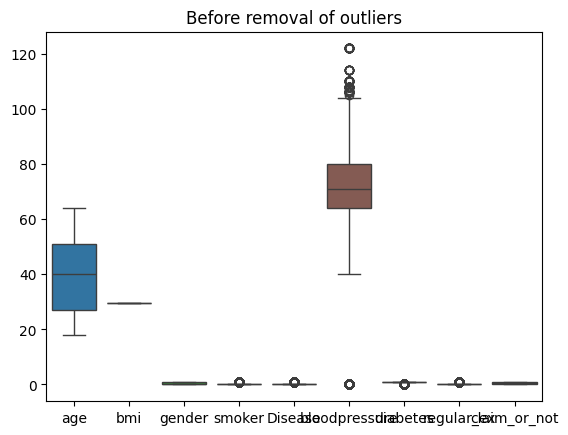

In [ ]:
sns.boxplot(data=data)
plt.title('Before removal of outliers')
plt.show()

In [ ]:
x=data[['age','bmi','gender','smoker','Disease','bloodpressure','diabetes','regular_ex']]
y=data['claim_or_not']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=RandomForestClassifier(n_estimators=1000,random_state=42)
model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=1000, random_state=42)

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
print(classification_report(y_test,y_pred,target_names=['not claim','claim']))

              precision    recall  f1-score   support

   not claim       0.97      0.98      0.98      1487
       claim       0.98      0.97      0.98      1513

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



In [ ]:
accuracy=accuracy_score(y_pred,y_test)
print("Random forest accuracy:",accuracy)

Random forest accuracy: 0.976


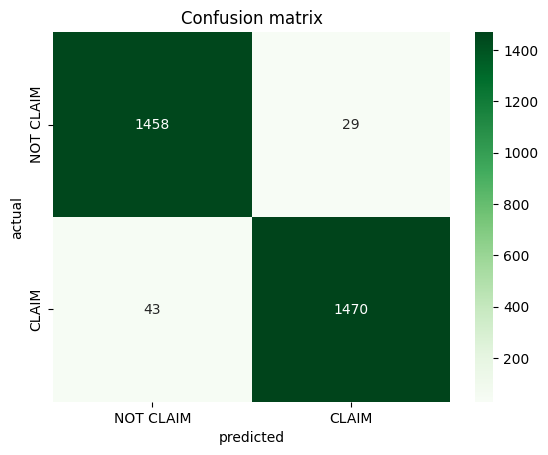

In [ ]:
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Greens',
            xticklabels=['NOT CLAIM','CLAIM'],
            yticklabels=['NOT CLAIM','CLAIM'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Confusion matrix')
plt.show()

In [ ]:
import joblib

In [ ]:
joblib.dump(model,'insurance.pkl', compress=9)

['insurance.pkl']

In [ ]:
files.download("insurance.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>